# CBB Strength/Ranking Credibility Project

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


## Importing necessary data from March Madness Mania Dataset

In [4]:
cbb_matchups = pd.read_csv("MRegularSeasonCompactResults.csv")
cbb_matchups2025 = cbb_matchups[cbb_matchups['Season'] == 2025]

cbb_teams = pd.read_csv("MTeams.csv")

cbb_winners = pd.merge(cbb_teams, cbb_matchups2025, left_on=["TeamID"] , right_on=["WTeamID"])
cbb_winners.rename(columns = {"TeamName": "WTeamName"}, inplace = True)

cbb_w_and_l = pd.merge(cbb_winners, cbb_teams, left_on=["LTeamID"], right_on=["TeamID"])
cbb_w_and_l.rename(columns = {"TeamName": "LTeamName"}, inplace = True)
cbb_w_and_l.columns
cbb_w_and_l_teams = cbb_w_and_l[["WTeamName", "LTeamName"]]
cbb_w_and_l_teams

,WTeamName,LTeamName
0,Abilene Chr,Texas St
1,Abilene Chr,Southern Miss
2,Abilene Chr,NE Omaha
3,Abilene Chr,New Mexico St
4,Abilene Chr,TX Southern
...,...,...
5636,West Georgia,Tennessee Tech
5637,West Georgia,Austin Peay
5638,West Georgia,North Florida
5639,West Georgia,Bellarmine


## Creating Graphs from Data

### Directed Graph (Results)

In [7]:
cbb_graph = nx.DiGraph()
for i in range(0, len(cbb_teams)):
    cbb_graph.add_node(cbb_teams.loc[i]["TeamName"])

print(cbb_graph)

DiGraph with 381 nodes and 0 edges


<function matplotlib.pyplot.show(close=None, block=None)>

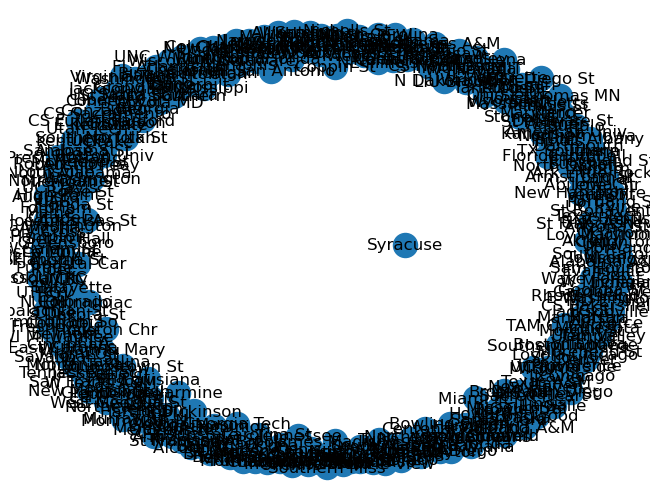

In [8]:
nx.draw(cbb_graph, with_labels = True)
plt.show

In [9]:
cbb_graph.edges

OutEdgeView([])

In [10]:
for k in range(0, len(cbb_w_and_l_teams)):
    if cbb_graph.has_edge(cbb_w_and_l_teams.loc[k]["LTeamName"], cbb_w_and_l_teams.loc[k]["WTeamName"]):
        cbb_graph[cbb_w_and_l_teams.loc[k]["LTeamName"]][cbb_w_and_l_teams.loc[k]["WTeamName"]]['weight'] += 1
    else:
        cbb_graph.add_edge(cbb_w_and_l_teams.loc[k]["LTeamName"], cbb_w_and_l_teams.loc[k]["WTeamName"], weight = 1)

print(cbb_graph)

DiGraph with 381 nodes and 4624 edges


<function matplotlib.pyplot.show(close=None, block=None)>

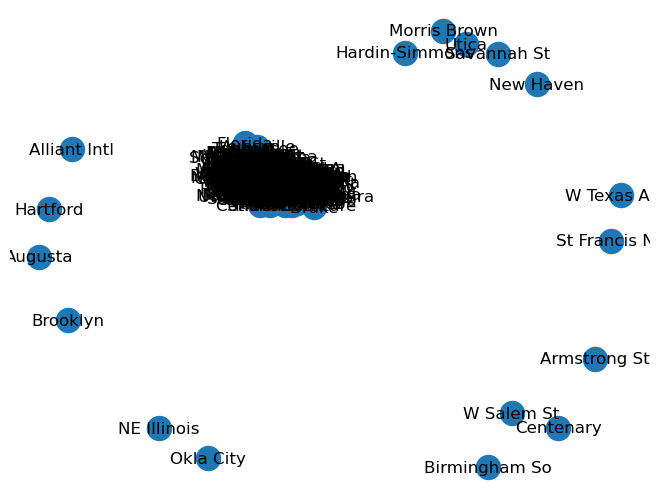

In [11]:
nx.draw(cbb_graph, with_labels = True)
plt.show

### Undirected Graph (Schedule)

In [13]:
cbb_graph_undirected = cbb_graph.to_undirected()
print(cbb_graph_undirected)

Graph with 381 nodes and 4043 edges


<function matplotlib.pyplot.show(close=None, block=None)>

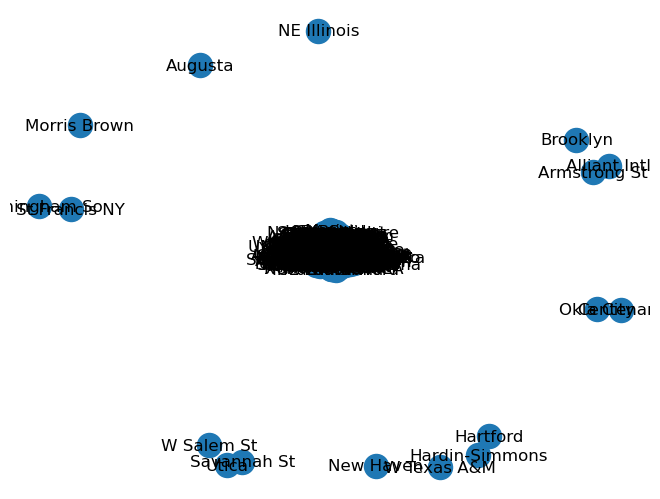

In [14]:
nx.draw(cbb_graph_undirected, with_labels = True)
plt.show

## Measures of Centrality

### In and Out Degree Centrality

In [17]:
cbb_graph.in_degree(weight="weight")
cbb_graph.out_degree(weight="weight")

in_degree_cent = nx.in_degree_centrality(cbb_graph)
print(max(in_degree_cent, key=in_degree_cent.get))
out_degree_cent = nx.out_degree_centrality(cbb_graph)
print(max(out_degree_cent, key=out_degree_cent.get))

Florida
Chicago St


### Eigenvector Centrality

In [19]:
eig_cent = nx.eigenvector_centrality(cbb_graph, weight="weight")
print(max(eig_cent, key=eig_cent.get))
eig_cent_sort_ascend = dict(sorted(eig_cent.items(), key=lambda item: item[1]))
print(eig_cent_sort_ascend["MS Valley St"]) # MS Valley St is the smallest eigenvector centrality of any school that played in 2025 D1 season

Auburn
4.282469825957783e-05


### Katz Centrality

In [21]:
katz_cent = nx.katz_centrality_numpy(cbb_graph, weight="weight")
print(max(katz_cent, key=katz_cent.get))
print(min(katz_cent, key=katz_cent.get))

Houston
Robert Morris


### Closeness Centrality

In [23]:
close_cent = nx.closeness_centrality(cbb_graph)
print(max(close_cent, key=close_cent.get))
close_cent_sort_ascend = dict(sorted(close_cent.items(), key=lambda item: item[1]))
print(close_cent_sort_ascend["MS Valley St"]) # MS Valley St is the smallest closeness centrality of any school that played in 2025 D1 season

Auburn
0.16989736713169498


### Betweenness Centrality

In [25]:
between_cent = nx.betweenness_centrality(cbb_graph, weight="weight")
print(max(between_cent, key=between_cent.get))
between_cent_sort_ascend = dict(sorted(between_cent.items(), key=lambda item: item[1]))
print(between_cent_sort_ascend["MS Valley St"]) # MS Valley St is the smallest closeness centrality of any school that played in 2025 D1 season

Wichita St
6.226868536531537e-05


## Creating Laplacian for Credibility Approximation

### Handmade Laplacian

In [28]:
schedule_adj = nx.to_pandas_adjacency(cbb_graph_undirected)
schedule_degree_mat = np.zeros(schedule_adj.shape)
for i in range(0, len(schedule_adj)):
    schedule_degree_mat[i, i] = sum(schedule_adj.iloc[i])

laplacian_hand = schedule_degree_mat - schedule_adj
laplacian_hand

,Abilene Chr,Air Force,Akron,Alabama,Alabama A&M,Alabama St,SUNY Albany,Alcorn St,Alliant Intl,American Univ,...,St Thomas MN,Lindenwood,Queens NC,Southern Indiana,Stonehill,East Texas A&M,Le Moyne,Mercyhurst,West Georgia,New Haven
Abilene Chr,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
Air Force,0.0,31.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
Akron,0.0,0.0,31.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alabama,0.0,0.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alabama A&M,0.0,0.0,0.0,0.0,28.0,-2.0,0.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
East Texas A&M,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,28.0,0.0,0.0,0.0,0.0
Le Moyne,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,0.0,26.0,-1.0,0.0,0.0
Mercyhurst,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,0.0,-1.0,23.0,0.0,0.0
West Georgia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,29.0,0.0


### NetworkX Laplacian (and is it equivalent to the handmade version)

In [30]:
schedule_lap = nx.laplacian_matrix(cbb_graph_undirected)
schedule_lap_dense = schedule_lap.todense()
is_same_test = np.array(laplacian_hand) == schedule_lap_dense
is_same_test.all()
# laplacian calculation by hand matches networkx calculation.

True

## Calculating Pseudoinverse of Laplacian

In [56]:
schedule_inv_lap = np.linalg.pinv(schedule_lap_dense)

array([[ 4.53240940e-02, -5.16659339e-05, -3.42301597e-04, ...,
        -7.69975133e-04, -2.56243235e-04,  0.00000000e+00],
       [-5.16659339e-05,  3.65204098e-02, -3.57991575e-04, ...,
         1.33933490e-03, -4.03240297e-04,  0.00000000e+00],
       [-3.42301597e-04, -3.57991575e-04,  3.60435226e-02, ...,
        -3.84456509e-04, -3.75545563e-04,  0.00000000e+00],
       ...,
       [-7.69975133e-04,  1.33933490e-03, -3.84456509e-04, ...,
         4.69320698e-02, -8.22318556e-04,  0.00000000e+00],
       [-2.56243235e-04, -4.03240297e-04, -3.75545563e-04, ...,
        -8.22318556e-04,  3.83160377e-02,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

## Calculating Credibility Approximation
$C_i^{\mathrm{graph}} = - \log((L^+)_{ii} + \epsilon)$

In [73]:
cred_approx = np.zeros(len(schedule_inv_lap))
epsilon = 1e-10
for i in range(0, len(schedule_inv_lap)):
    cred_approx[i] = -np.log(schedule_inv_lap[i, i] + epsilon)

min_cred_index = np.where(cred_approx == min(cred_approx))
cbb_teams[

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026
...,...,...,...,...
376,1477,East Texas A&M,2023,2026
377,1478,Le Moyne,2024,2026
378,1479,Mercyhurst,2025,2026
379,1480,West Georgia,2025,2026
